In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df = pd.read_parquet('datasets/model_data.parquet')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543727 entries, 0 to 543726
Data columns (total 44 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   mun_istat                  543727 non-null  object  
 1   year                       543727 non-null  int64   
 2   covid                      543727 non-null  int64   
 3   mun_name                   543727 non-null  object  
 4   mun_name_norm              543727 non-null  object  
 5   location                   543727 non-null  category
 6   region                     543727 non-null  object  
 7   prov                       543727 non-null  object  
 8   prov_istat                 543727 non-null  object  
 9   sector                     543727 non-null  category
 10  type                       543727 non-null  object  
 11  condition                  543727 non-null  category
 12  log_buy_min                543727 non-null  float64 
 13  log_buy_max   

Province

In [57]:
df_prov = df.groupby(['year','prov'], observed=True).agg({                      
    'covid': 'first',
    'location': 'first',
    'region': 'first',
    'prov_istat': 'first',
    'log_buy_min': 'mean',
    'log_buy_max': 'mean',
    'log_buy_avg': 'mean',
    'population': 'sum',
    'reg_age_avg':'mean',
    'over65':'mean',
    'log_median_income': 'mean',
    'dwellings': 'sum',
    'prov_immigration': 'mean',
    'prov_emigration': 'mean',
    'prov_net_movements': 'mean',
    'log_real_gdp': 'mean',
    'log_nominal_gdp' : 'mean',
    'unemployment_prov': 'mean',
    'ratio_hotel_beds': 'mean',
    'ratio_hotel_mun': 'mean',
    'ratio_str_beds': 'mean',
    'ratio_str_mun': 'mean',
    'ratio_str_mun_beds': 'mean',
    'ratio_arrivals': 'mean',
    'ratio_arrivals_foreigners': 'mean',
    'tourism_score': 'mean',
    'log_tour_employed' : 'mean'
}).reset_index()

col_to_np = ['population', 'prov_immigration', 'prov_emigration']

for col in col_to_np:
    df_prov['log_' + col] = np.log(df[col] + 1)

df_prov['log_reg_age_avg'] = np.log(df_prov['reg_age_avg'])

df_prov.to_csv('datasets/prov_model_data.csv', index=False)

Province with growth rates

In [58]:
df_prov_growth = df_prov.copy()

# compute growth rates for estimates (min, max, avg), gdp, and income 
columns_growth = ['log_buy_min','log_buy_max','log_buy_avg','log_reg_age_avg','log_nominal_gdp', 'log_median_income', 'log_population','unemployment_prov','log_prov_immigration','log_prov_emigration']

for col in columns_growth:
    df_prov_growth['growth_' + col] = (df_prov_growth.groupby(df_prov_growth["prov"])[col].diff())

df_prov_growth = df_prov_growth.dropna()

df_prov_growth.to_csv('datasets/prov_growth_model_data.csv', index=False)

In [19]:
df_prov_growth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1100 entries, 110 to 1209
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   year                       1100 non-null   int64   
 1   prov                       1100 non-null   object  
 2   covid                      1100 non-null   int64   
 3   location                   1100 non-null   category
 4   region                     1100 non-null   object  
 5   prov_istat                 1100 non-null   object  
 6   log_buy_min                1100 non-null   float64 
 7   log_buy_max                1100 non-null   float64 
 8   log_buy_avg                1100 non-null   float64 
 9   population                 1100 non-null   float64 
 10  reg_age_avg                1100 non-null   float64 
 11  over65                     1100 non-null   float64 
 12  log_median_income          1100 non-null   float64 
 13  dwellings                  1100 non-

Visualise data

Text(0, 0.5, 'Logged maximum selling price')

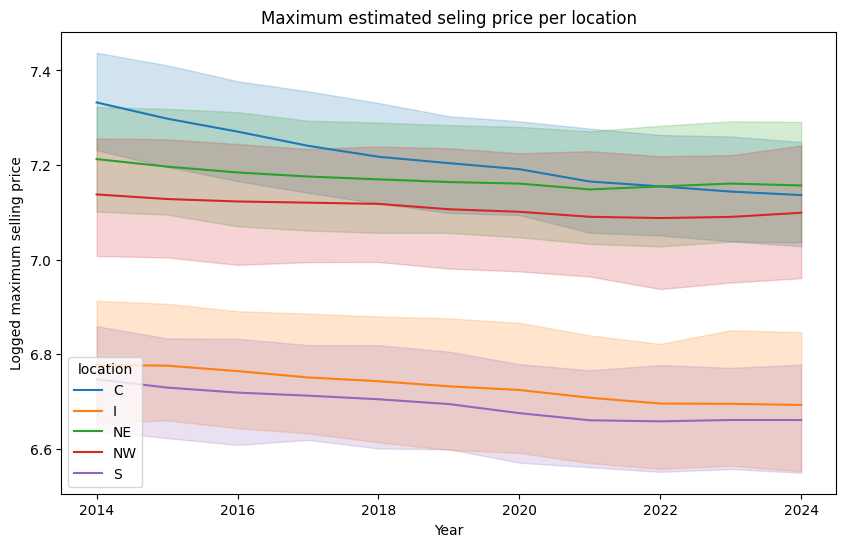

In [31]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'log_buy_max', x = 'year', hue = 'location')
plt.title('Maximum estimated seling price per location')
plt.xlabel('Year')
plt.ylabel('Logged maximum selling price')

Text(0, 0.5, 'Growth rate')

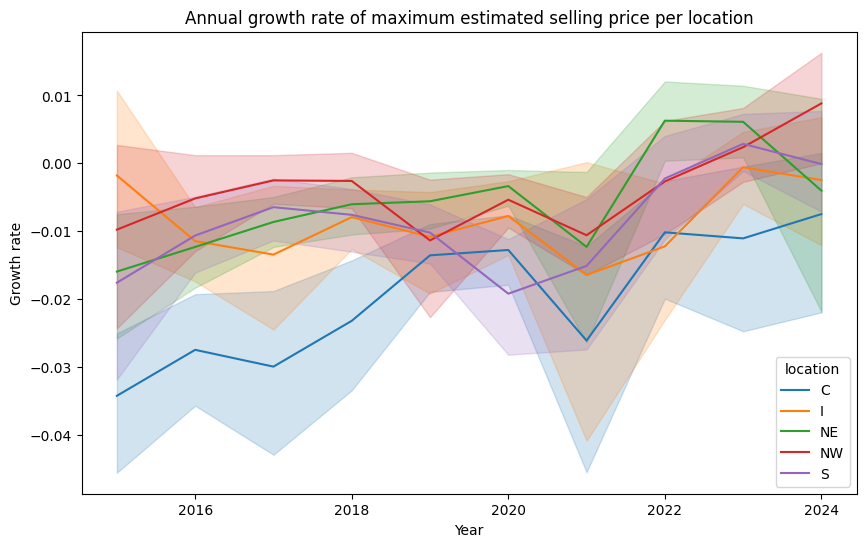

In [43]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov_growth, y = 'growth_log_buy_max', x = 'year', hue = 'location')
plt.title('Annual growth rate of maximum estimated selling price per location')
plt.xlabel('Year')
plt.ylabel('Growth rate')

Text(0, 0.5, 'Tourism score')

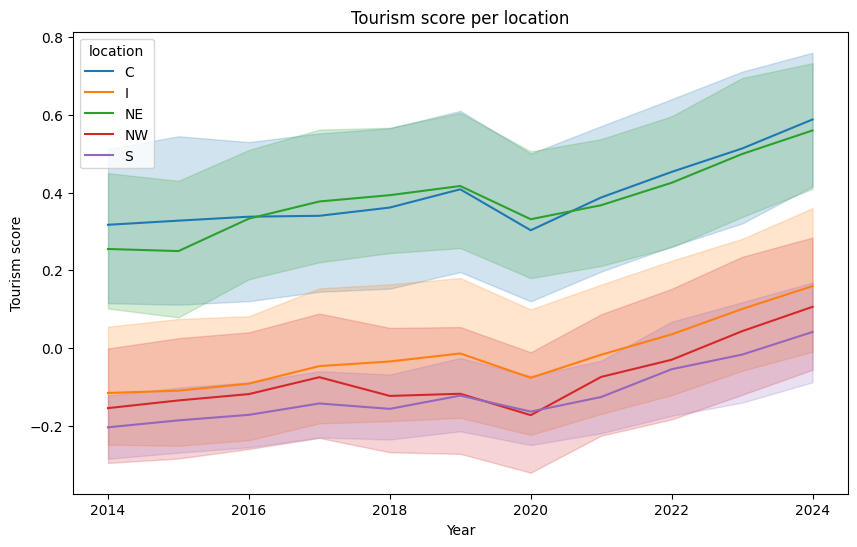

In [41]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'tourism_score', x = 'year', hue = 'location')
plt.title('Tourism score per location')
plt.xlabel('Year')
plt.ylabel('Tourism score')

Text(0, 0.5, 'Logged median income')

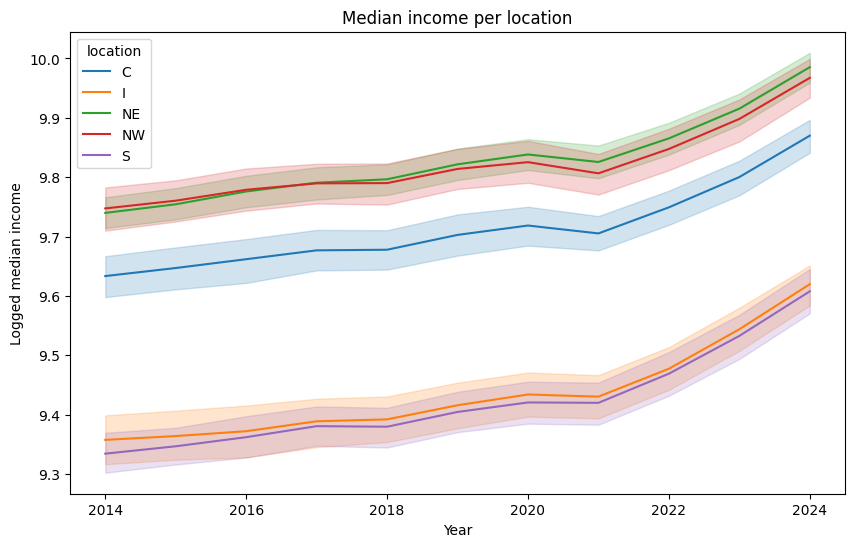

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'log_median_income', x = 'year', hue = 'location')
plt.title('Median income per location')
plt.xlabel('Year')
plt.ylabel('Logged median income')

Text(0, 0.5, 'Growth rate')

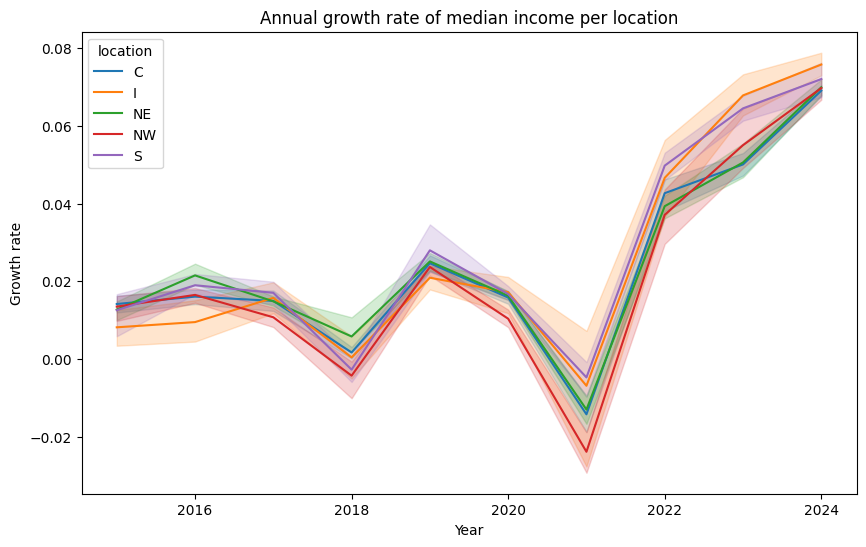

In [45]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov_growth, y = 'growth_log_median_income', x = 'year', hue = 'location')
plt.title('Annual growth rate of median income per location')
plt.xlabel('Year')
plt.ylabel('Growth rate')

Text(0, 0.5, 'Logged population')

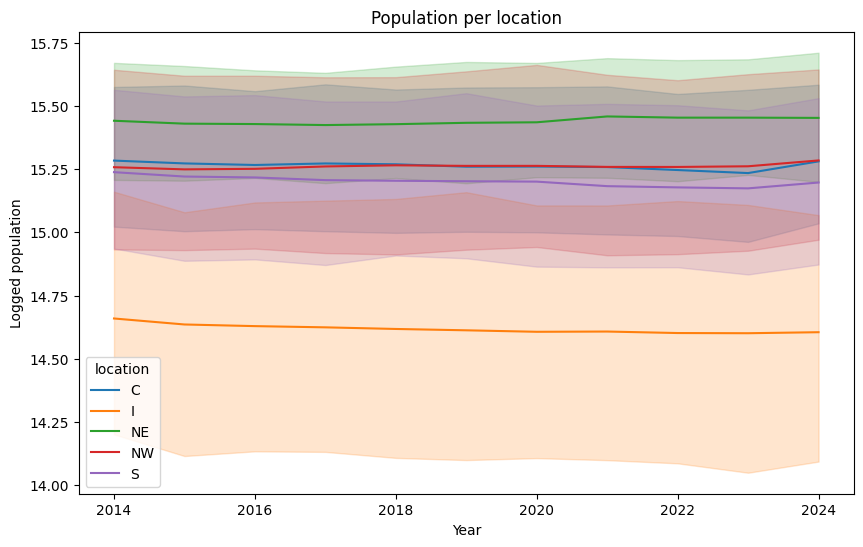

In [33]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'log_population', x = 'year', hue = 'location')
plt.title('Population per location')
plt.xlabel('Year')
plt.ylabel('Logged population')

Text(0, 0.5, 'Growth rate')

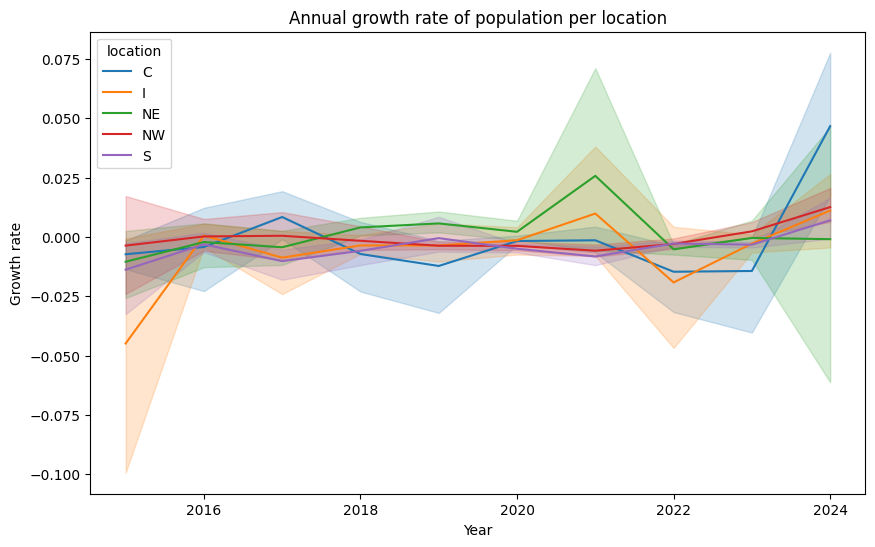

In [46]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov_growth, y = 'growth_log_population', x = 'year', hue = 'location')
plt.title('Annual growth rate of population per location')
plt.xlabel('Year')
plt.ylabel('Growth rate')

Text(0, 0.5, 'Average age')

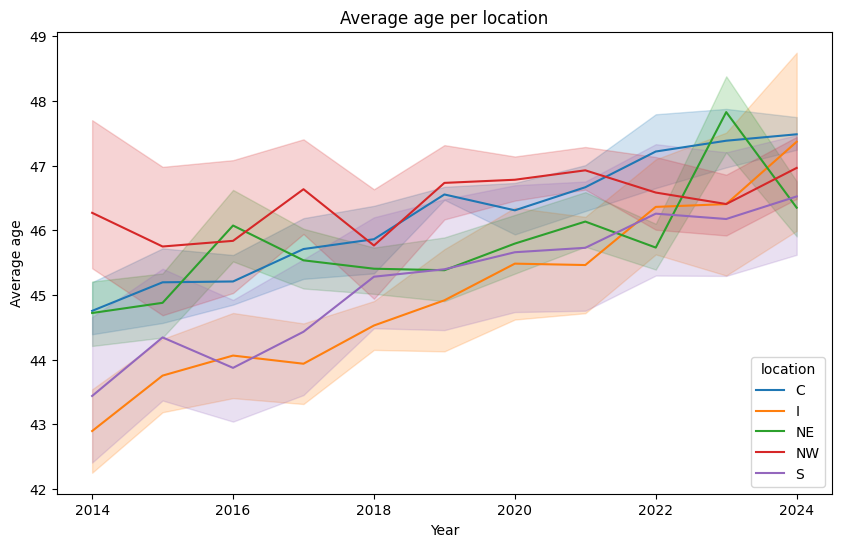

In [34]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'reg_age_avg', x = 'year', hue = 'location')
plt.title('Average age per location')
plt.xlabel('Year')
plt.ylabel('Average age')

Text(0, 0.5, 'Net migration movements')

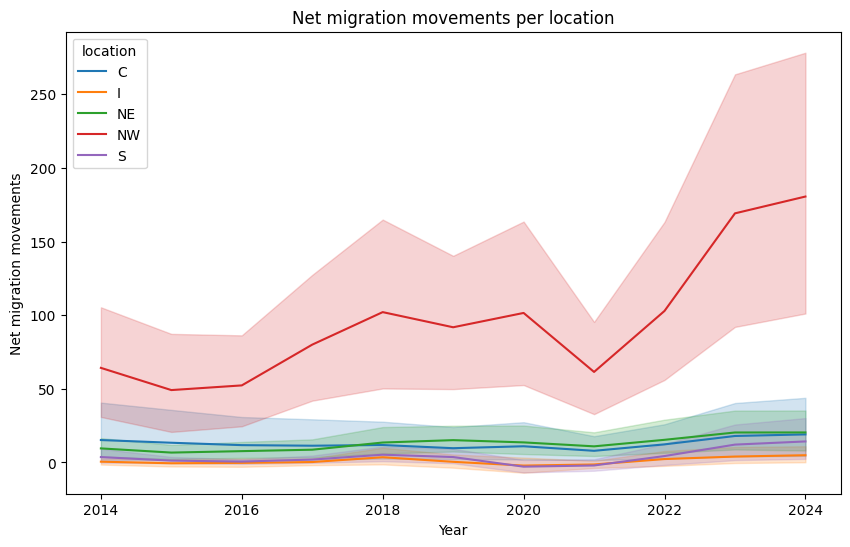

In [35]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'prov_net_movements', x = 'year', hue = 'location')
plt.title('Net migration movements per location')
plt.xlabel('Year')
plt.ylabel('Net migration movements')

Text(0, 0.5, 'Number of immigrants')

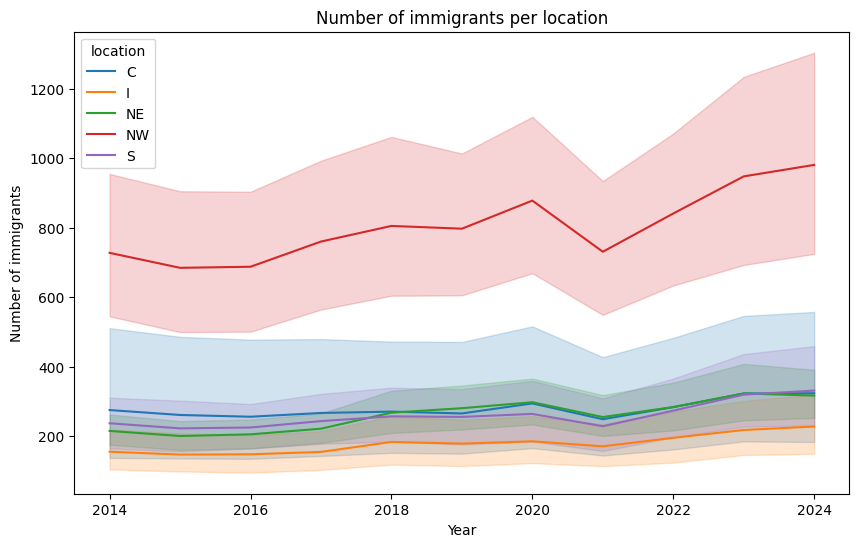

In [59]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'prov_immigration', x = 'year', hue = 'location')
plt.title('Number of immigrants per location')
plt.xlabel('Year')
plt.ylabel('Number of immigrants')

Text(0, 0.5, 'Number of emigrants')

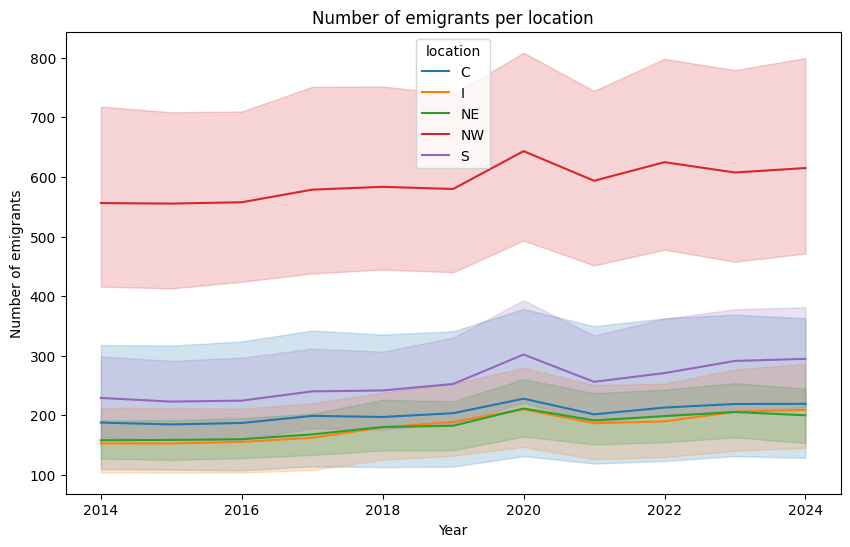

In [60]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'prov_emigration', x = 'year', hue = 'location')
plt.title('Number of emigrants per location')
plt.xlabel('Year')
plt.ylabel('Number of emigrants')

Text(0, 0.5, 'Growth rate')

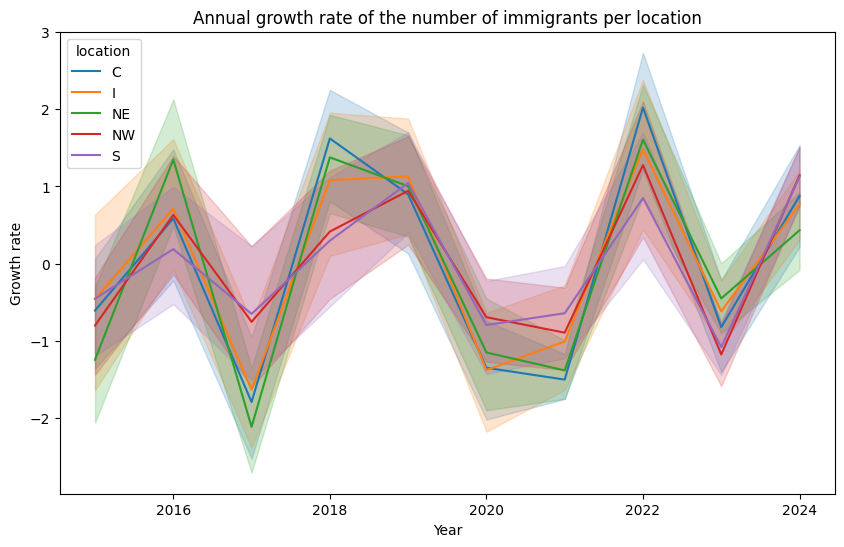

In [62]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov_growth, y = 'growth_log_prov_immigration', x = 'year', hue = 'location')
plt.title('Annual growth rate of the number of immigrants per location')
plt.xlabel('Year')
plt.ylabel('Growth rate')

Text(0, 0.5, 'Growth rate')

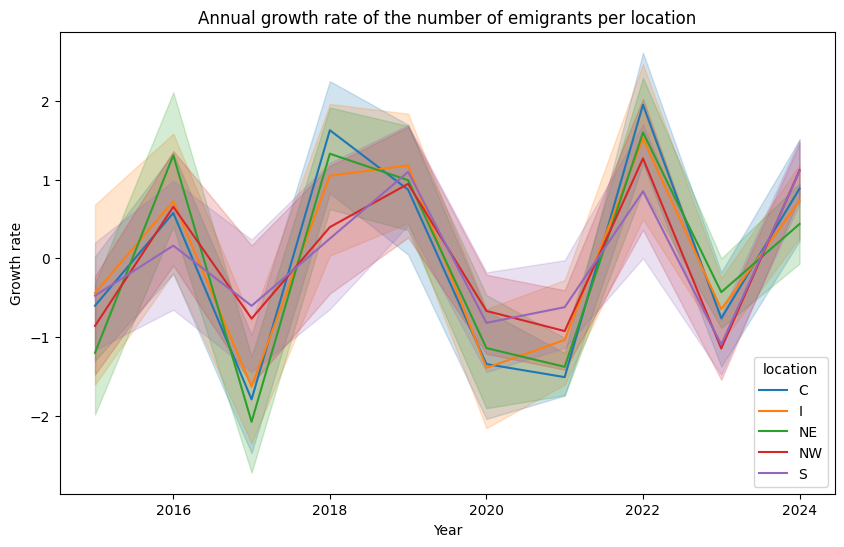

In [63]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov_growth, y = 'growth_log_prov_emigration', x = 'year', hue = 'location')
plt.title('Annual growth rate of the number of emigrants per location')
plt.xlabel('Year')
plt.ylabel('Growth rate')

Text(0, 0.5, 'Unemployment rate')

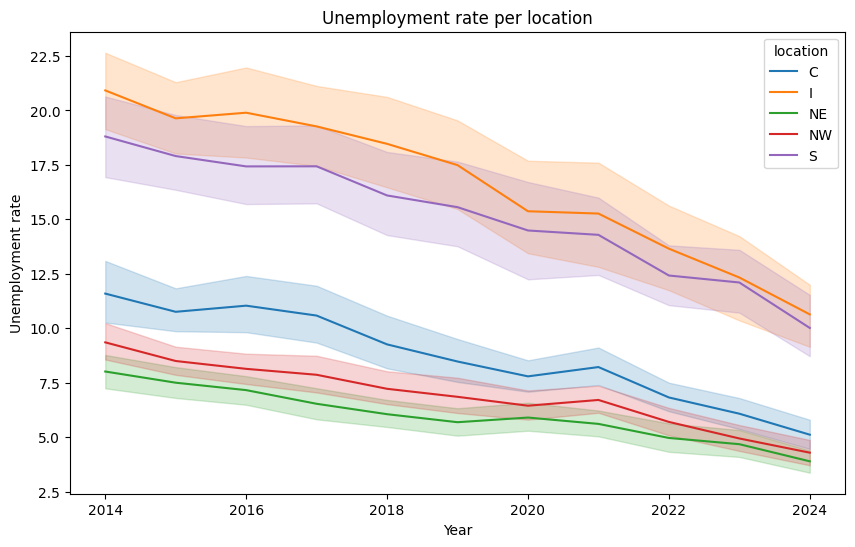

In [36]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'unemployment_prov', x = 'year', hue = 'location')
plt.title('Unemployment rate per location')
plt.xlabel('Year')
plt.ylabel('Unemployment rate')

Text(0, 0.5, 'Log nominal GDP')

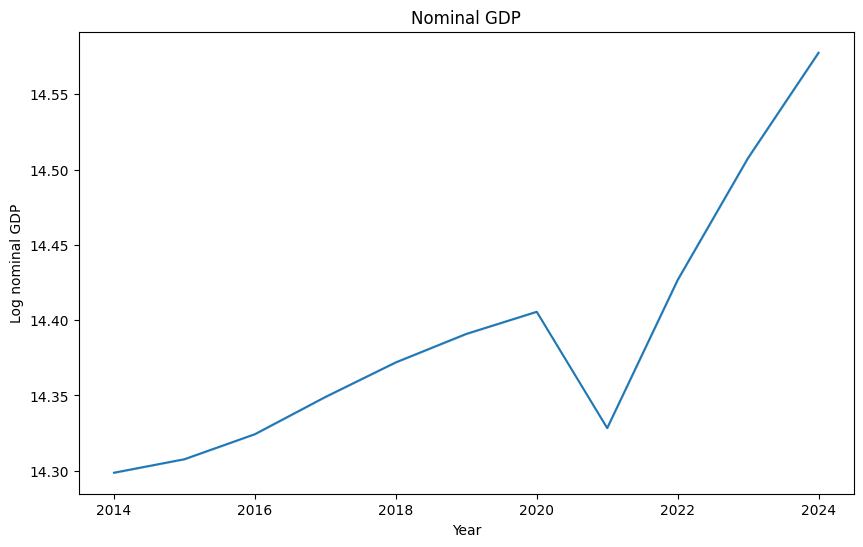

In [40]:
plt.figure(figsize=(10,6))
sns.lineplot(data = df_prov, y = 'log_nominal_gdp', x = 'year')
plt.title('Nominal GDP')
plt.xlabel('Year')
plt.ylabel('Log nominal GDP')

Province with municiplities > 10,000 inhabitants

In [10]:
df_prov_select = df[df['population'] > 5000].copy()

df_prov_select = df_prov_select.groupby(['prov','year'], observed=True).agg({ 
    'covid': 'first',
    'location': 'first',
    'region': 'first',
    'prov_istat': 'first',
    'log_buy_min': 'mean',
    'log_buy_max': 'mean',
    'log_buy_avg': 'mean',
    'population': 'sum',
    'reg_age_avg':'mean',
    'over65':'mean',
    'log_median_income': 'mean',
    'dwellings': 'sum',
    'prov_immigration': 'mean',
    'prov_emigration': 'mean',
    'prov_net_movements': 'mean',
    'log_real_gdp': 'mean',
    'log_nominal_gdp' : 'mean',
    'unemployment_prov': 'mean',
    'ratio_hotel_beds': 'mean',
    'ratio_hotel_mun': 'mean',
    'ratio_str_beds': 'mean',
    'ratio_str_mun': 'mean',
    'ratio_str_mun_beds': 'mean',
    'ratio_arrivals': 'mean',
    'ratio_arrivals_foreigners': 'mean',
    'tourism_score': 'mean',
    'log_tour_employed' : 'mean'
}).reset_index()

df_prov_select['log_population'] = np.log(df_prov_select['population'])

df_prov_select.to_csv('datasets/prov_select_model_data.csv', index = None)

Cities with growth rates

In [15]:
df_prov_select_growth = df_prov_select.copy()

# compute growth rates for estimates (min, max, avg), gdp, and income 
columns_growth = ['log_buy_min','log_buy_max','log_buy_avg','log_nominal_gdp', 'log_median_income', 'log_population']

for col in columns_growth:
    df_prov_select_growth['growth_' + col] = (df_prov_select_growth.groupby(df_prov_select_growth["prov"])[col].diff())

df_prov_select_growth = df_prov_select_growth.dropna()

df_prov_select_growth.to_csv('datasets/prov_select_growth_model_data.csv', index=False)